In [5]:
from VF2 import VF2, Graph, find_subgraph_match

In [2]:


def build_G1():
    G = Graph()
    for i in range(5): G.add_node(i)
    for u, v in [(0, 2), (1, 2), (2, 3), (2, 4)]: G.add_edge(u, v)
    return G

def build_G2():
    G = Graph()
    for i in range(9): G.add_node(i)
    # This is a 3x3 grid-like graph
    edges = [(0,1),(0,3),(1,2),(1,4),(2,5),(3,4),(3,6),(4,5),(4,7),(5,8),(6,7),(7,8)]
    for u, v in edges: G.add_edge(u, v)
    return G

G1, G2 = build_G1(), build_G2()
# state = VF2State(G1, G2)
found, mapping = find_subgraph_match(G1, G2)

print("Found:", found)
print("Mapping:", mapping)

def test_star_in_clique():
    # G1: Star Graph (Node 0 is center)
    G1 = Graph()
    for i in range(5): G1.add_node(i)
    for i in range(1, 5): G1.add_edge(0, i)

    # G2: K5 Clique (5 nodes, all connected)
    G2 = Graph()
    for i in range(5): G2.add_node(i)
    import itertools
    for u, v in itertools.combinations(range(5), 2):
        G2.add_edge(u, v)

    found, mapping = find_subgraph_match(G1, G2)
    print(f"Test 1 (Star in Clique): {found}, Mapping: {mapping}")

def test_label_mismatch():
    G1 = Graph()
    G1.add_node(0, label="A")
    G1.add_node(1, label="B")
    G1.add_edge(0, 1)

    G2 = Graph()
    G2.add_node(10, label="A")
    G2.add_node(11, label="C") # 'C' instead of 'B'
    G2.add_edge(10, 11)

    found, mapping = find_subgraph_match(G1, G2)
    print(f"Test 2 (Label Mismatch): {found} (Expected False)")

def test_path_search():
    G1 = Graph()
    for i in range(4): G1.add_node(i)
    for i in range(3): G1.add_edge(i, i+1)

    G2 = Graph()
    for i in range(6): G2.add_node(i)
    for i in range(5): G2.add_edge(i, i+1)

    found, mapping = find_subgraph_match(G1, G2)
    print(f"Test 3 (Path in Path): {found}, Mapping: {mapping}")

def test_cycles():
    # G1: Triangle
    G1 = Graph()
    for i in range(3): G1.add_node(i)
    G1.add_edge(0, 1); G1.add_edge(1, 2); G1.add_edge(2, 0)

    # G2: Square
    G2 = Graph()
    for i in range(4): G2.add_node(i)
    G2.add_edge(0, 1); G2.add_edge(1, 2); G2.add_edge(2, 3); G2.add_edge(3, 0)

    found, mapping = find_subgraph_match(G1, G2)
    print(f"Test 4 (Triangle in Square): {found} (Expected False)")

test_star_in_clique()
test_label_mismatch()
test_path_search()
test_cycles()

Found: True
Mapping: {0: 1, 2: 4, 1: 3, 3: 5, 4: 7}
Test 1 (Star in Clique): True, Mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
Test 2 (Label Mismatch): False (Expected False)
Test 3 (Path in Path): True, Mapping: {0: 0, 1: 1, 2: 2, 3: 3}
Test 4 (Triangle in Square): False (Expected False)


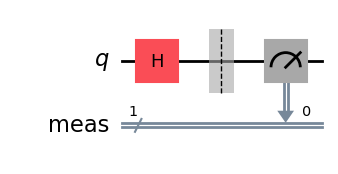

In [1]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(1) # Create a quantum circuit  with one qubit
qc.h(0) # Apply a hadamard gate to the only qubit
qc.measure_all() # Measure the qubit
qc.draw('mpl')

In [ ]:
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer


dag = circuit_to_dag(qc)

In [13]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure_all()

# Create qubit connectivity graph
graph = Graph()

# Add all qubits as nodes
for q in qc.qubits:
    graph.add_node(q, label=str(q))

# Add edges for every 2-qubit gate
for instr, qargs, cargs in qc.data:
    if len(qargs) == 2:  # two-qubit gate
        q0, q1 = qargs
        graph.add_edge(q0, q1)

# Print graph
for node, neighbors in graph.adj.items():
    print(f"Qubit {node}: connected to {[n for n in neighbors]}")

Qubit <Qubit register=(3, "q"), index=0>: connected to [<Qubit register=(3, "q"), index=1>]
Qubit <Qubit register=(3, "q"), index=1>: connected to [<Qubit register=(3, "q"), index=2>, <Qubit register=(3, "q"), index=0>]
Qubit <Qubit register=(3, "q"), index=2>: connected to [<Qubit register=(3, "q"), index=1>]


C:\Users\Nanu\AppData\Local\Temp\ipykernel_4848\3319837117.py:15: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, cargs in qc.data:


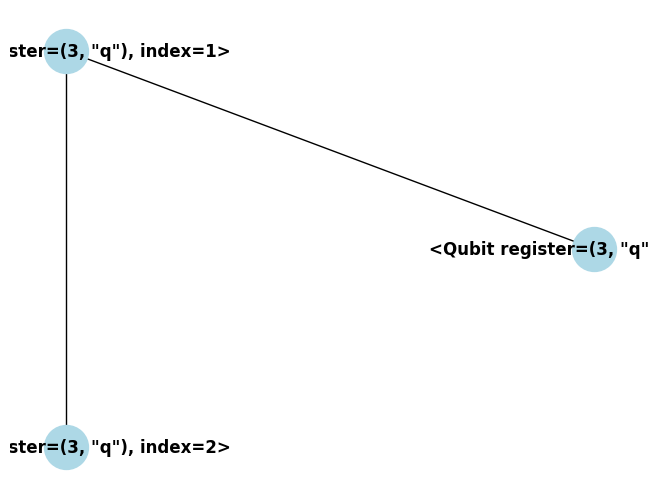

In [9]:
import matplotlib.pyplot as plt
import networkx as nx  # optional, easier layout
def draw_graph(graph):
    G = nx.Graph()
    # Add nodes with labels
    for node in graph.adj:
        G.add_node(str(node))  # networkx needs hashable nodes
    # Add edges
    for node, neighbors in graph.adj.items():
        for n in neighbors:
            G.add_edge(str(node), str(n))
    
    pos = nx.circular_layout(G)  # circular layout for qubits
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=12, font_weight='bold')
    plt.show()

draw_graph(graph)

In [2]:
from qiskit.providers.fake_provider import GenericBackendV2
backend_custom = GenericBackendV2(
    num_qubits=4,
    basis_gates=["x", "sx", "rz", "cx"], 
    coupling_map=[[0,1], [1,2], [2,3]],
    seed=123
)
from VF2 import VF2, Graph, find_subgraph_match
G2 = Graph()

print(backend_custom.coupling_map)

for i in range (backend_custom.num_qubits):
            G2.add_node(i)
        
for x, y in backend_custom.coupling_map:
    G2.add_edge(x, y)

for node, neighbors in G2.adj.items():
    print(f"Qubit {node}: connected to {[n for n in neighbors]}")

[[0, 1], [1, 2], [2, 3]]
Qubit 0: connected to [1]
Qubit 1: connected to [0, 2]
Qubit 2: connected to [1, 3]
Qubit 3: connected to [2]


In [ ]:
from transpiler.passes.layout.layout import Layout

qc = QuantumCircuit(3)
qc.cx(0,1)
qc.cx(1,2)
# qc.cx(2,0)


backend_custom = GenericBackendV2(
    num_qubits=4,
    basis_gates=["x", "sx", "rz", "cx"], 
    coupling_map=[[0,1], [1,2], [2,3]],
    seed=123
)

found, mapping = Layout.run_layout(qc, backend_custom)

print(f"Found {found}, with the mapping {mapping}")

Found True, with the mapping {0: 0, 1: 1, 2: 2}


In [23]:
for q in qc.qubits:
    idx, regs = qc.find_bit(q)
    print(idx)

0
1
2
